Gerando Gráfico de Homogeneidade (PT)...


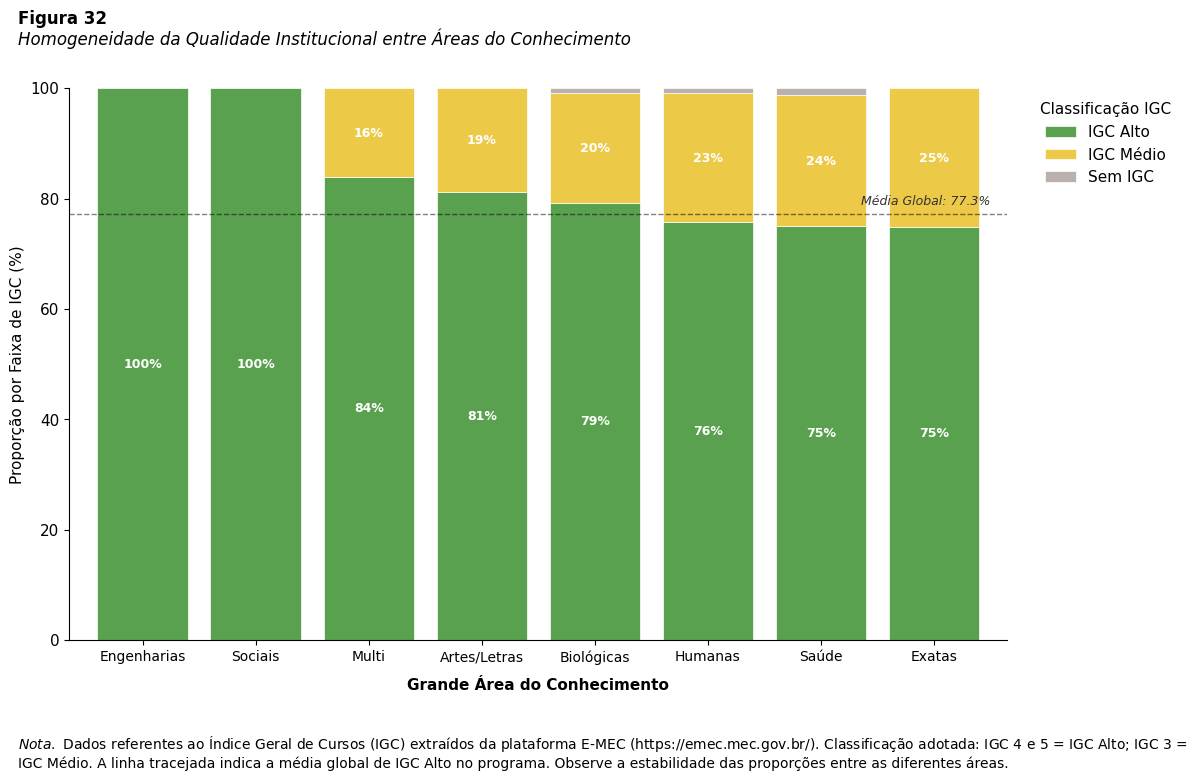

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==============================================================================
# CONFIGURAÇÃO
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_igc = 'igc_categoria'

# FILTRO METODOLÓGICO (Conforme Relatório)
# "Análise restrita às Instituições de Ensino Superior (tem_igc = 1)"
# Se a coluna 'tem_igc' existir, usamos ela. Se não, usamos não-nulos em igc_categoria.
if 'tem_igc' in df.columns:
    df = df[df['tem_igc'] == 1].copy()
else:
    df = df.dropna(subset=[col_igc])

df = df.dropna(subset=[col_area])
df = df[df[col_area] != 'Não aplicável']

# Mapeamento de Áreas
mapa_areas = {
    'Ciências Exatas e da Terra': 'Exatas',
    'Ciências Biológicas': 'Biológicas',
    'Engenharias': 'Engenharias',
    'Ciências da Saúde': 'Saúde',
    'Ciências Agrárias': 'Agrárias',
    'Ciências Sociais Aplicadas': 'Sociais',
    'Ciências Humanas': 'Humanas',
    'Linguística, Letras e Artes': 'Artes/Letras',
    'Multidisciplinar': 'Multi'
}
df['area_plot'] = df[col_area].map(mapa_areas).fillna(df[col_area])

# ==============================================================================
# PLOTAGEM
# ==============================================================================
def plot_igc_area_homogeneity_pt():
    # Crosstab normalizado (100% dentro da área)
    ct = pd.crosstab(df['area_plot'], df[col_igc], normalize='index') * 100

    # Ordenação das colunas de IGC (Visual: Alto em baixo ou em cima?)
    # Vamos colocar "IGC Alto" na base para facilitar a comparação com a régua visual
    ordem_igc = ['IGC Alto', 'IGC Médio', 'Sem IGC']
    ct = ct.reindex(columns=[c for c in ordem_igc if c in ct.columns])

    # Ordenar as Áreas por % de IGC Alto (para mostrar a suave escada, se houver)
    ct = ct.sort_values('IGC Alto', ascending=False)

    # Calcular média global de IGC Alto para a linha de referência
    global_high = (df[col_igc] == 'IGC Alto').mean() * 100

    fig, ax = plt.subplots(figsize=(12, 7))

    # Cores
    colors = {
        'IGC Alto': '#59a14f',   # Verde (Excelência)
        'IGC Médio': '#edc948',  # Amarelo (Médio)
        'Sem IGC': '#bab0ac'     # Cinza (Residual)
    }
    color_list = [colors.get(c, '#bab0ac') for c in ct.columns]

    # Plot
    ct.plot(kind='bar', stacked=True, width=0.8, color=color_list, ax=ax, edgecolor='white', linewidth=0.5)

    # Linha de Referência (Média Global)
    ax.axhline(global_high, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.text(len(ct)-0.5, global_high + 1, f'Média Global: {global_high:.1f}%',
            va='bottom', ha='right', fontsize=9, style='italic', color='#333')

    # Rótulos
    for c in ax.containers:
        # Apenas rótulos > 4%
        labels = [f'{v.get_height():.0f}%' if v.get_height() > 4 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', weight='bold')

    ax.set_xlabel("Grande Área do Conhecimento", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Proporção por Faixa de IGC (%)", fontsize=11)
    ax.set_ylim(0, 100)
    plt.xticks(rotation=0, ha='center', fontsize=10)

    # Legenda
    ax.legend(title="Classificação IGC", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    # Títulos e Nota Específica
    fig.text(0.02, 0.98, "Figura 32", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Homogeneidade da Qualidade Institucional entre Áreas do Conhecimento", fontsize=12, style='italic')

    # Nota exigida
    note = (r"$\it{Nota.}$ Dados referentes ao Índice Geral de Cursos (IGC) extraídos da plataforma E-MEC "
            r"(https://emec.mec.gov.br/). Classificação adotada: IGC 4 e 5 = IGC Alto; IGC 3 = IGC Médio. "
            r"A linha tracejada indica a média global de IGC Alto no programa. "
            r"Observe a estabilidade das proporções entre as diferentes áreas.")
    fig.text(0.02, -0.08, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig32_igc_area_homogeneity_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Gráfico de Homogeneidade (PT)...")
plot_igc_area_homogeneity_pt()

Gerando Gráfico de Homogeneidade (EN)...


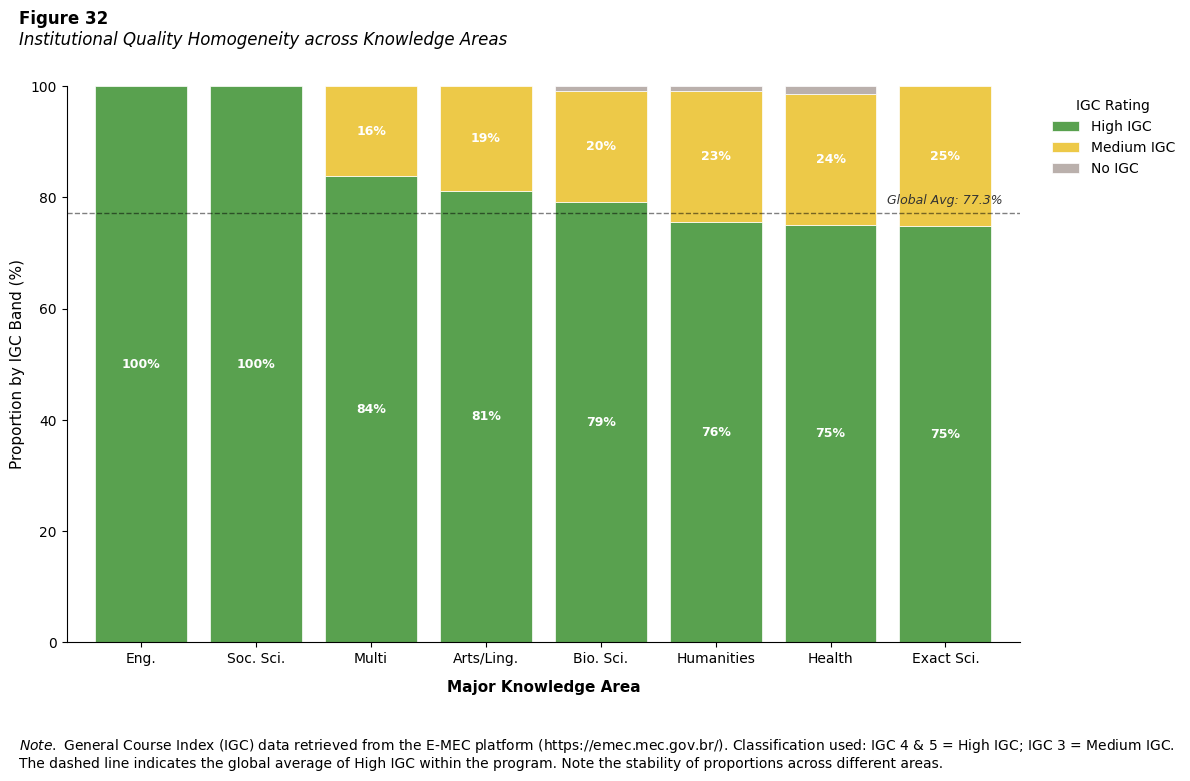

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Config
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

try:
    df = pd.read_csv("2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv")
    if 'tem_igc' in df.columns:
        df = df[df['tem_igc'] == 1].copy()
    else:
        df = df.dropna(subset=['igc_categoria'])
    df = df.dropna(subset=['grande_area - area_macro_CAPES'])
    df = df[df['grande_area - area_macro_CAPES'] != 'Não aplicável']
except:
    df = pd.DataFrame()

# Mapeamentos EN
mapa_igc_en = {'IGC Alto': 'High IGC', 'IGC Médio': 'Medium IGC', 'Sem IGC': 'No IGC'}
df['igc_en'] = df['igc_categoria'].map(mapa_igc_en)

mapa_areas_en = {
    'Ciências Exatas e da Terra': 'Exact Sci.', 'Ciências Biológicas': 'Bio. Sci.',
    'Engenharias': 'Eng.', 'Ciências da Saúde': 'Health',
    'Ciências Agrárias': 'Agrarian', 'Ciências Sociais Aplicadas': 'Soc. Sci.',
    'Ciências Humanas': 'Humanities', 'Linguística, Letras e Artes': 'Arts/Ling.',
    'Multidisciplinar': 'Multi'
}
df['area_en'] = df['grande_area - area_macro_CAPES'].map(mapa_areas_en).fillna('Other')

def plot_igc_area_homogeneity_en():
    ct = pd.crosstab(df['area_en'], df['igc_en'], normalize='index') * 100

    ordem_igc = ['High IGC', 'Medium IGC', 'No IGC']
    ct = ct.reindex(columns=[c for c in ordem_igc if c in ct.columns])
    ct = ct.sort_values('High IGC', ascending=False)

    global_high = (df['igc_en'] == 'High IGC').mean() * 100

    fig, ax = plt.subplots(figsize=(12, 7))

    colors = {'High IGC': '#59a14f', 'Medium IGC': '#edc948', 'No IGC': '#bab0ac'}
    color_list = [colors.get(c, '#bab0ac') for c in ct.columns]

    ct.plot(kind='bar', stacked=True, width=0.8, color=color_list, ax=ax, edgecolor='white', linewidth=0.5)

    ax.axhline(global_high, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.text(len(ct)-0.5, global_high + 1, f'Global Avg: {global_high:.1f}%',
            va='bottom', ha='right', fontsize=9, style='italic', color='#333')

    for c in ax.containers:
        labels = [f'{v.get_height():.0f}%' if v.get_height() > 4 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', weight='bold')

    ax.set_xlabel("Major Knowledge Area", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Proportion by IGC Band (%)", fontsize=11)
    ax.set_ylim(0, 100)
    plt.xticks(rotation=0, ha='center', fontsize=10)

    ax.legend(title="IGC Rating", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    fig.text(0.02, 0.98, "Figure 32", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Institutional Quality Homogeneity across Knowledge Areas", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ General Course Index (IGC) data retrieved from the E-MEC platform "
            r"(https://emec.mec.gov.br/). Classification used: IGC 4 & 5 = High IGC; IGC 3 = Medium IGC. "
            r"The dashed line indicates the global average of High IGC within the program. "
            r"Note the stability of proportions across different areas.")
    fig.text(0.02, -0.08, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig32_igc_area_homogeneity_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Gráfico de Homogeneidade (EN)...")
plot_igc_area_homogeneity_en()

Gerando Heatmap Frio (PT)...


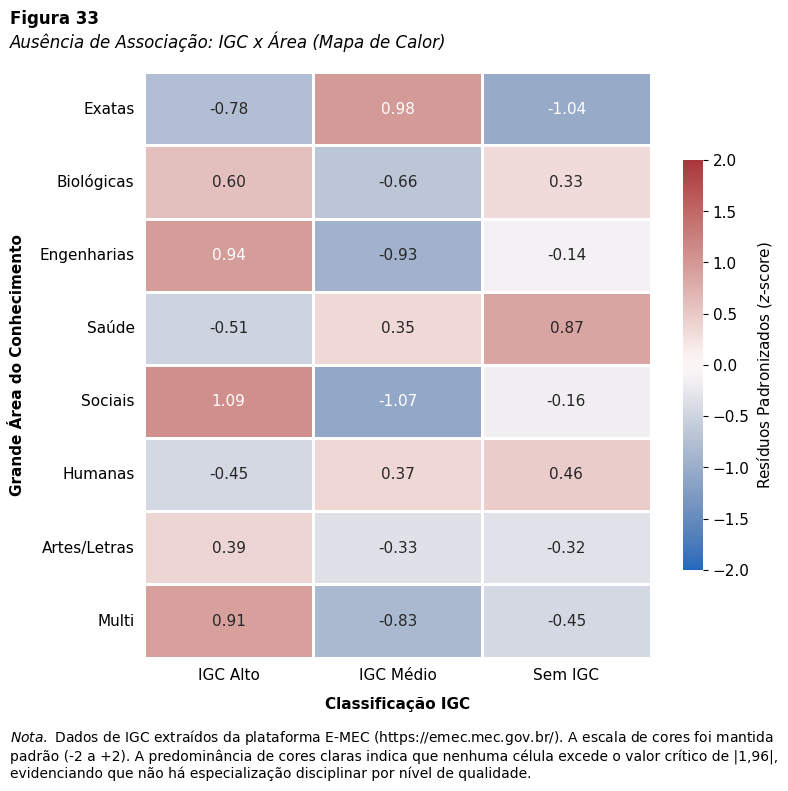

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from matplotlib import rcParams

# ==============================================================================
# CONFIGURAÇÃO
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_igc = 'igc_categoria'

# Filtro: Apenas IES (tem_igc = 1) conforme relatório
if 'tem_igc' in df.columns:
    df = df[df['tem_igc'] == 1].copy()
else:
    df = df.dropna(subset=[col_igc])

df = df.dropna(subset=[col_area])
df = df[df[col_area] != 'Não aplicável']

# Mapeamentos PT
mapa_areas = {
    'Ciências Exatas e da Terra': 'Exatas',
    'Ciências Biológicas': 'Biológicas',
    'Engenharias': 'Engenharias',
    'Ciências da Saúde': 'Saúde',
    'Ciências Agrárias': 'Agrárias',
    'Ciências Sociais Aplicadas': 'Sociais',
    'Ciências Humanas': 'Humanas',
    'Linguística, Letras e Artes': 'Artes/Letras',
    'Multidisciplinar': 'Multi'
}
df['area_plot'] = df[col_area].map(mapa_areas).fillna(df[col_area])

# ==============================================================================
# CÁLCULO DOS RESÍDUOS
# ==============================================================================
def get_adj_residuals(data, col_x, col_y):
    ct = pd.crosstab(data[col_y], data[col_x])
    observed = ct.values
    chi2, p, dof, expected = chi2_contingency(observed)

    with np.errstate(divide='ignore', invalid='ignore'):
        n = observed.sum()
        row_p = observed.sum(axis=1) / n
        col_p = observed.sum(axis=0) / n
        div = np.sqrt(expected * (1 - row_p[:, np.newaxis]) * (1 - col_p[np.newaxis, :]))
        adj_res = (observed - expected) / div

    return pd.DataFrame(adj_res, index=ct.index, columns=ct.columns).fillna(0)

# ==============================================================================
# PLOTAGEM (HEATMAP FRIO)
# ==============================================================================
def plot_heatmap_cold_pt():
    residuos = get_adj_residuals(df, 'igc_categoria', 'area_plot')

    # Ordenação Lógica
    ordem_igc = ['IGC Alto', 'IGC Médio', 'Sem IGC']
    # Ordenação Áreas (mesma dos outros gráficos para consistência)
    ordem_areas = ['Exatas', 'Biológicas', 'Engenharias', 'Saúde',
                   'Sociais', 'Humanas', 'Artes/Letras', 'Multi']

    residuos = residuos.reindex(index=ordem_areas, columns=ordem_igc)

    fig, ax = plt.subplots(figsize=(8, 8))

    # Heatmap com escala TRAVADA em -2 a 2 para forçar a visualização "pálida"
    # Isso demonstra visualmente que os valores são baixos
    sns.heatmap(residuos, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-2, vmax=2,
                linewidths=1, linecolor='white', cbar_kws={'label': 'Resíduos Padronizados ($z$-score)', 'shrink': 0.7}, ax=ax)

    ax.set_xlabel("Classificação IGC", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Grande Área do Conhecimento", weight='bold', fontsize=11, labelpad=10)
    plt.xticks(rotation=0, ha='center')
    plt.yticks(rotation=0)
    ax.tick_params(left=False, bottom=False)

    fig.text(0.02, 0.96, "Figura 33", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Ausência de Associação: IGC x Área (Mapa de Calor)", fontsize=12, style='italic')

    # Nota com fonte E-MEC e explicação do "gráfico frio"
    note = (r"$\it{Nota.}$ Dados de IGC extraídos da plataforma E-MEC (https://emec.mec.gov.br/). "
            "A escala de cores foi mantida padrão (-2 a +2). A predominância de cores claras indica que "
            "nenhuma célula excede o valor crítico de |1,96|, evidenciando que não há especialização disciplinar por nível de qualidade.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("apa_fig33_heatmap_cold_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Heatmap Frio (PT)...")
plot_heatmap_cold_pt()

Gerando Heatmap Frio (EN)...


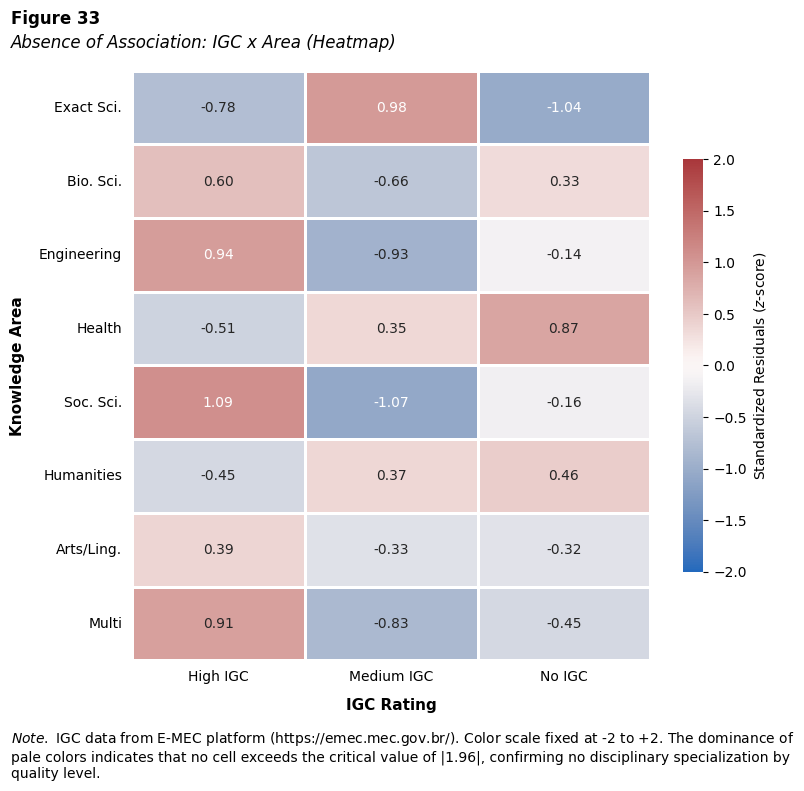

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from matplotlib import rcParams

# Config
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

try:
    df = pd.read_csv("2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv")
    if 'tem_igc' in df.columns:
        df = df[df['tem_igc'] == 1].copy()
    else:
        df = df.dropna(subset=['igc_categoria'])
    df = df.dropna(subset=['grande_area - area_macro_CAPES'])
    df = df[df['grande_area - area_macro_CAPES'] != 'Não aplicável']
except:
    df = pd.DataFrame()

# Mapeamentos EN
mapa_igc_en = {'IGC Alto': 'High IGC', 'IGC Médio': 'Medium IGC', 'Sem IGC': 'No IGC'}
df['igc_en'] = df['igc_categoria'].map(mapa_igc_en)

mapa_areas_en = {
    'Ciências Exatas e da Terra': 'Exact Sci.', 'Ciências Biológicas': 'Bio. Sci.',
    'Engenharias': 'Engineering', 'Ciências da Saúde': 'Health',
    'Ciências Agrárias': 'Agrarian', 'Ciências Sociais Aplicadas': 'Soc. Sci.',
    'Ciências Humanas': 'Humanities', 'Linguística, Letras e Artes': 'Arts/Ling.',
    'Multidisciplinar': 'Multi'
}
df['area_en'] = df['grande_area - area_macro_CAPES'].map(mapa_areas_en).fillna('Other')

def get_adj_residuals(data, col_x, col_y):
    ct = pd.crosstab(data[col_y], data[col_x])
    observed = ct.values
    chi2, p, dof, expected = chi2_contingency(observed)
    with np.errstate(divide='ignore', invalid='ignore'):
        n = observed.sum()
        row_p = observed.sum(axis=1) / n
        col_p = observed.sum(axis=0) / n
        div = np.sqrt(expected * (1 - row_p[:, np.newaxis]) * (1 - col_p[np.newaxis, :]))
        adj_res = (observed - expected) / div
    return pd.DataFrame(adj_res, index=ct.index, columns=ct.columns).fillna(0)

def plot_heatmap_cold_en():
    residuos = get_adj_residuals(df, 'igc_en', 'area_en')

    ordem_igc = ['High IGC', 'Medium IGC', 'No IGC']
    ordem_areas = ['Exact Sci.', 'Bio. Sci.', 'Engineering', 'Health',
                   'Soc. Sci.', 'Humanities', 'Arts/Ling.', 'Multi']

    residuos = residuos.reindex(index=ordem_areas, columns=ordem_igc)

    fig, ax = plt.subplots(figsize=(8, 8))

    # Heatmap FRIO
    sns.heatmap(residuos, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-2, vmax=2,
                linewidths=1, linecolor='white', cbar_kws={'label': 'Standardized Residuals ($z$-score)', 'shrink': 0.7}, ax=ax)

    ax.set_xlabel("IGC Rating", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Knowledge Area", weight='bold', fontsize=11, labelpad=10)
    plt.xticks(rotation=0, ha='center')
    plt.yticks(rotation=0)
    ax.tick_params(left=False, bottom=False)

    fig.text(0.02, 0.96, "Figure 33", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Absence of Association: IGC x Area (Heatmap)", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ IGC data from E-MEC platform (https://emec.mec.gov.br/). "
            "Color scale fixed at -2 to +2. The dominance of pale colors indicates that no cell exceeds "
            "the critical value of |1.96|, confirming no disciplinary specialization by quality level.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("apa_fig33_heatmap_cold_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Heatmap Frio (EN)...")
plot_heatmap_cold_en()